In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display
import warnings

import ast

warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 전역 시드 설정 (재현성을 위해)
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [2]:
# 프로모션 데이터 불러오기 (새로 추가된 코드)
promotion = pd.read_csv('./data/promotion_df.csv')
merged = pd.read_csv('./data/all_merged.csv')


# 고객 세그먼트별 전환/이탈률 보기

“우리는 단순히 이벤트가 있었는지를 세는 게 아니라,
오퍼 퍼널의 순서가 맞는지까지 확인해서 전환율을 계산하고 있다.
그래서 viewed_flag는 received <= viewed, completed_after_view_flag는 viewed <= completed로 정의해야 한다.
이렇게 해야 열람률과 완료율이 실제 퍼널 의미에 맞게 계산된다.”

In [3]:
# 세그먼트 분석용 데이터 복사 (bogo랑 discount만!)
seg_df = promotion[promotion['offer_type'].isin(['bogo', 'discount'])].copy()

# 공통 플래그 만들기
# seg_df['viewed_flag'] = seg_df['offer viewed'].notna().astype(int)로 해도 
# 건수 자체가 received로 시작하는 열만 존재해서 received <= viewed를 이미 충족하고 있음
# 다만 의도를 명확히 전달하기 위해 표기
seg_df['viewed_flag'] = ((seg_df['offer received'] <= seg_df['offer viewed'])).astype(int)

# viewed이후 completed로 설정하는 이유
# - 정상 퍼널 기준으로 봐야 하는 이유: 퍼널은 순서가 있는 행동 흐름이라서, 비정상 순서를 빼야 전환/이탈률이 의미 있음
seg_df['completed_after_view_flag'] = ((seg_df['offer viewed'] <= seg_df['offer completed'])).astype(int)


In [4]:
seg_df

,person,offer_id,offer_cycle,offer received,offer viewed,offer completed,offer_type,difficulty,reward,duration,...,completion_amount,promo_influenced_amount,amount,is_received,is_viewed,is_completed,is_normal_flow,is_deduplicated,viewed_flag,completed_after_view_flag
0,0009655768c64bdeb2e877511632db8f,bogo_5_5_5,Bogo_1,408.0,456.0,414.0,bogo,5,5,5,...,8.57,0.00,8.57,1,1,1,0,0,1,0
1,0009655768c64bdeb2e877511632db8f,discount_10_2_10,Discount_1,504.0,540.0,528.0,discount,10,2,10,...,14.11,0.00,14.11,1,1,1,0,0,1,0
2,0009655768c64bdeb2e877511632db8f,discount_10_2_7,Discount_1,576.0,NaN,576.0,discount,10,2,7,...,10.27,NaN,10.27,1,0,1,0,0,0,0
3,0011e0d4e6b944f998e987f904e8c1e5,discount_7_3_7,Discount_1,168.0,186.0,252.0,discount,7,3,7,...,11.93,11.93,11.93,1,1,1,1,1,1,1
4,0011e0d4e6b944f998e987f904e8c1e5,bogo_5_5_7,Bogo_1,504.0,516.0,576.0,bogo,5,5,7,...,22.05,22.05,22.05,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76266,ffc77312ccda49fca19506f1cdf44923,bogo_5_5_7,Bogo_1,168.0,NaN,NaN,bogo,5,5,7,...,NaN,NaN,NaN,1,0,0,0,0,0,0
76267,ffc77312ccda49fca19506f1cdf44923,discount_7_3_7,Discount_1,336.0,NaN,NaN,discount,7,3,7,...,NaN,NaN,NaN,1,0,0,0,0,0,0
76271,ffe5257abf8840b395e1ee6b29894637,discount_20_5_10,Discount_2,504.0,NaN,NaN,discount,20,5,10,...,NaN,NaN,NaN,1,0,0,0,0,0,0
76273,ffede3b700ac41d6a266fa1ba74b4f16,discount_20_5_10,Discount_1,504.0,NaN,NaN,discount,20,5,10,...,NaN,NaN,NaN,1,0,0,0,0,0,0


In [20]:
seg_df["age"].isna().sum()

np.int64(0)

In [22]:
seg_df.columns

Index(['person', 'offer_id', 'offer_cycle', 'offer received', 'offer viewed',
       'offer completed', 'offer_type', 'difficulty', 'reward', 'duration',
       'web', 'email', 'mobile', 'social', 'gender', 'age', 'became_member_on',
       'income', 'amount_raw', 'completion_amount', 'promo_influenced_amount',
       'amount', 'is_received', 'is_viewed', 'is_completed', 'is_normal_flow',
       'is_deduplicated', 'viewed_flag', 'completed_after_view_flag',
       'age_group', 'income_group'],
      dtype='str')

# bogo + discount 전체에 대한 비율 먼저 확인

In [5]:
gender_summary = seg_df.groupby('gender').agg(
    total_offers=('person', 'count'),
    viewed=('viewed_flag', 'sum'),
    completed=('completed_after_view_flag', 'sum')
).reset_index()

gender_summary['view_rate(%)'] = (gender_summary['viewed'] / gender_summary['total_offers'] * 100).round(1)
gender_summary['view_drop_rate(%)'] = (100 - gender_summary['view_rate(%)']).round(1)
gender_summary['completion_rate(%)'] = (gender_summary['completed'] / gender_summary['viewed'] * 100).round(1)
gender_summary['received_to_complete_rate(%)'] = (gender_summary['completed'] / gender_summary['total_offers'] * 100).round(1)
gender_summary['completion_drop_rate(%)'] = (100 - gender_summary['completion_rate(%)']).round(1)

display(
    gender_summary[
        [
            'gender',
            'total_offers',
            'viewed',
            'completed',
            'view_rate(%)',
            'view_drop_rate(%)',
            'completion_rate(%)',
            'completion_drop_rate(%)',
            'received_to_complete_rate(%)'
        ]
    ].sort_values('total_offers', ascending=False)
)


,gender,total_offers,viewed,completed,view_rate(%),view_drop_rate(%),completion_rate(%),completion_drop_rate(%),received_to_complete_rate(%)
1,M,30562,23012,11522,75.3,24.7,50.1,49.9,37.7
0,F,21918,16876,10426,77.0,23.0,61.8,38.2,47.6
2,O,721,612,386,84.9,15.1,63.1,36.9,53.5


| flow_type | 흐름 설명                     | 비고            |
|-----------|------------------------------|-----------------|
| 0         | 받기 → 완료 → 보기            | 비정상 흐름      |
| 1         | 받기 → 보기 → 완료            | 정상 흐름        |
| 2         | 받기 → 완료                   | 보기 없이 완료   |
| 3         | 받기 → 보기                   | 완료 없이 보기   |
| 4         | 받기만                        | 반응 없음        |

| 지표     | 분자                                   | 분모                                   |
|----------|----------------------------------------|----------------------------------------|
| 열람율   | flow_type.isin([1,3])의 is_viewed       | flow_type.isin([1,2,3,4])의 count      |
| 전환율   | flow_type.isin([1,3])의 is_completed    | flow_type.isin([1,2,3,4])의 count      |
| 완료율   | flow_type.isin([0,1,2,3,4])의 is_completed | flow_type.isin([0,1,2,3,4])의 count |
| 정상흐름비중 | flow_type == 1의 count | flow_type.isin([0,1,2,3,4])의 count |

In [6]:
seg_df['age_group'] = pd.cut(
    seg_df['age'],
    bins=[0, 20, 30, 40, 50, 60, 70, 120],
    labels=['10s', '20s', '30s', '40s', '50s', '60s', '70+'],
    right=False
)

seg_df['age_group'] = seg_df['age_group'].astype('object').fillna('Unknown')

age_summary = seg_df.groupby('age_group').agg(
    total_offers=('person', 'count'),
    viewed=('viewed_flag', 'sum'),
    completed=('completed_after_view_flag', 'sum')
).reset_index()

age_summary['view_rate(%)'] = (age_summary['viewed'] / age_summary['total_offers'] * 100).round(1)
age_summary['view_drop_rate(%)'] = (100 - age_summary['view_rate(%)']).round(1)
age_summary['completion_rate(%)'] = (age_summary['completed'] / age_summary['viewed'] * 100).round(1)
age_summary['received_to_complete_rate(%)'] = (age_summary['completed'] / age_summary['total_offers'] * 100).round(1)
age_summary['completion_drop_rate(%)'] = (100 - age_summary['completion_rate(%)']).round(1)

display(
    age_summary[
        [
            'age_group',
            'total_offers',
            'viewed',
            'completed',
            'view_rate(%)',
            'view_drop_rate(%)',
            'completion_rate(%)',
            'completion_drop_rate(%)',
            'received_to_complete_rate(%)'
        ]
    ]
)


,age_group,total_offers,viewed,completed,view_rate(%),view_drop_rate(%),completion_rate(%),completion_drop_rate(%),received_to_complete_rate(%)
0,10s,722,512,204,70.9,29.1,39.8,60.2,28.3
1,20s,4997,3512,1557,70.3,29.7,44.3,55.7,31.2
2,30s,5515,4039,2093,73.2,26.8,51.8,48.2,38.0
3,40s,8241,6561,3600,79.6,20.4,54.9,45.1,43.7
4,50s,12692,9704,5629,76.5,23.5,58.0,42.0,44.4
5,60s,10780,8330,4710,77.3,22.7,56.5,43.5,43.7
6,70+,18095,14236,5474,78.7,21.3,38.5,61.5,30.3


In [7]:
seg_df['income_group'] = pd.cut(
    seg_df['income'],
    bins=[0, 40000, 60000, 80000, 100000, float('inf')],
    labels=['0-40k', '40-60k', '60-80k', '80-100k', '100k+'],
    right=False
)

seg_df['income_group'] = seg_df['income_group'].astype('object').fillna('Unknown')

income_summary = seg_df.groupby('income_group').agg(
    total_offers=('person', 'count'),
    viewed=('viewed_flag', 'sum'),
    completed=('completed_after_view_flag', 'sum')
).reset_index()

income_summary['view_rate(%)'] = (income_summary['viewed'] / income_summary['total_offers'] * 100).round(1)
income_summary['view_drop_rate(%)'] = (100 - income_summary['view_rate(%)']).round(1)
income_summary['completion_rate(%)'] = (income_summary['completed'] / income_summary['viewed'] * 100).round(1)
income_summary['received_to_complete_rate(%)'] = (income_summary['completed'] / income_summary['total_offers'] * 100).round(1)
income_summary['completion_drop_rate(%)'] = (100 - income_summary['completion_rate(%)']).round(1)

display(
    income_summary[
        [
            'income_group',
            'total_offers',
            'viewed',
            'completed',
            'view_rate(%)',
            'view_drop_rate(%)',
            'completion_rate(%)',
            'completion_drop_rate(%)',
            'received_to_complete_rate(%)'
        ]
    ].sort_values('total_offers', ascending=False)
)


,income_group,total_offers,viewed,completed,view_rate(%),view_drop_rate(%),completion_rate(%),completion_drop_rate(%),received_to_complete_rate(%)
3,60-80k,16712,13084,7530,78.3,21.7,57.6,42.4,45.1
2,40-60k,16101,12083,6000,75.0,25.0,49.7,50.3,37.3
4,80-100k,9364,7645,4900,81.6,18.4,64.1,35.9,52.3
5,Unknown,7841,6394,933,81.5,18.5,14.6,85.4,11.9
0,0-40k,7072,4941,2076,69.9,30.1,42.0,58.0,29.4
1,100k+,3952,2747,1828,69.5,30.5,66.5,33.5,46.3


비율적 차이가 있는지 보려면 z비율

# 이후 Offer_type별 비교

In [8]:
offer_type_gender = seg_df.groupby(['offer_type', 'gender']).agg(
    total_offers=('person', 'count'),
    viewed=('viewed_flag', 'sum'),
    completed=('completed_after_view_flag', 'sum')
).reset_index()

offer_type_gender['view_rate(%)'] = (offer_type_gender['viewed'] / offer_type_gender['total_offers'] * 100).round(1)
offer_type_gender['view_drop_rate(%)'] = (100 - offer_type_gender['view_rate(%)']).round(1)
offer_type_gender['completion_rate(%)'] = (offer_type_gender['completed'] / offer_type_gender['viewed'] * 100).round(1)
offer_type_gender['received_to_complete_rate(%)'] = (offer_type_gender['completed'] / offer_type_gender['total_offers'] * 100).round(1)
offer_type_gender['completion_drop_rate(%)'] = (100 - offer_type_gender['completion_rate(%)']).round(1)

display(
    offer_type_gender[
        ['offer_type', 'gender', 'total_offers', 'viewed', 'completed',
         'view_rate(%)', 'view_drop_rate(%)',
         'completion_rate(%)', 'completion_drop_rate(%)', 'received_to_complete_rate(%)']
    ].sort_values(['offer_type', 'total_offers'], ascending=[True, False])
)


,offer_type,gender,total_offers,viewed,completed,view_rate(%),view_drop_rate(%),completion_rate(%),completion_drop_rate(%),received_to_complete_rate(%)
1,bogo,M,15208,12581,5236,82.7,17.3,41.6,58.4,34.4
0,bogo,F,10975,9143,5221,83.3,16.7,57.1,42.9,47.6
2,bogo,O,354,315,190,89.0,11.0,60.3,39.7,53.7
4,discount,M,15354,10431,6286,67.9,32.1,60.3,39.7,40.9
3,discount,F,10943,7733,5205,70.7,29.3,67.3,32.7,47.6
5,discount,O,367,297,196,80.9,19.1,66.0,34.0,53.4


In [9]:
offer_type_age = seg_df.groupby(['offer_type', 'age_group']).agg(
    total_offers=('person', 'count'),
    viewed=('viewed_flag', 'sum'),
    completed=('completed_after_view_flag', 'sum')
).reset_index()

offer_type_age['view_rate(%)'] = (offer_type_age['viewed'] / offer_type_age['total_offers'] * 100).round(1)
offer_type_age['view_drop_rate(%)'] = (100 - offer_type_age['view_rate(%)']).round(1)
offer_type_age['completion_rate(%)'] = (offer_type_age['completed'] / offer_type_age['viewed'] * 100).round(1)
offer_type_age['received_to_complete_rate(%)'] = (offer_type_age['completed'] / offer_type_age['total_offers'] * 100).round(1)
offer_type_age['completion_drop_rate(%)'] = (100 - offer_type_age['completion_rate(%)']).round(1)

display(
    offer_type_age[
        ['offer_type', 'age_group', 'total_offers', 'viewed', 'completed',
         'view_rate(%)', 'view_drop_rate(%)',
         'completion_rate(%)', 'completion_drop_rate(%)', 'received_to_complete_rate(%)']
    ].sort_values(['offer_type', 'age_group'])
)


,offer_type,age_group,total_offers,viewed,completed,view_rate(%),view_drop_rate(%),completion_rate(%),completion_drop_rate(%),received_to_complete_rate(%)
0,bogo,10s,381,308,86,80.8,19.2,27.9,72.1,22.6
1,bogo,20s,2450,2003,696,81.8,18.2,34.7,65.3,28.4
2,bogo,30s,2710,2220,954,81.9,18.1,43.0,57.0,35.2
3,bogo,40s,4184,3595,1724,85.9,14.1,48.0,52.0,41.2
4,bogo,50s,6322,5222,2727,82.6,17.4,52.2,47.8,43.1
5,bogo,60s,5349,4412,2219,82.5,17.5,50.3,49.7,41.5
6,bogo,70+,9103,7689,2535,84.5,15.5,33.0,67.0,27.8
7,discount,10s,341,204,118,59.8,40.2,57.8,42.2,34.6
8,discount,20s,2547,1509,861,59.2,40.8,57.1,42.9,33.8
9,discount,30s,2805,1819,1139,64.8,35.2,62.6,37.4,40.6


In [10]:
offer_type_income = seg_df.groupby(['offer_type', 'income_group']).agg(
    total_offers=('person', 'count'),
    viewed=('viewed_flag', 'sum'),
    completed=('completed_after_view_flag', 'sum')
).reset_index()

offer_type_income['view_rate(%)'] = (offer_type_income['viewed'] / offer_type_income['total_offers'] * 100).round(1)
offer_type_income['view_drop_rate(%)'] = (100 - offer_type_income['view_rate(%)']).round(1)
offer_type_income['completion_rate(%)'] = (offer_type_income['completed'] / offer_type_income['viewed'] * 100).round(1)
offer_type_income['received_to_complete_rate(%)'] = (offer_type_income['completed'] / offer_type_income['total_offers'] * 100).round(1)
offer_type_income['completion_drop_rate(%)'] = (100 - offer_type_income['completion_rate(%)']).round(1)

display(
    offer_type_income[
        ['offer_type', 'income_group', 'total_offers', 'viewed', 'completed',
         'view_rate(%)', 'view_drop_rate(%)',
         'completion_rate(%)', 'completion_drop_rate(%)', 'received_to_complete_rate(%)']
    ].sort_values(['offer_type', 'income_group'])
)


,offer_type,income_group,total_offers,viewed,completed,view_rate(%),view_drop_rate(%),completion_rate(%),completion_drop_rate(%),received_to_complete_rate(%)
0,bogo,0-40k,3571,2854,892,79.9,20.1,31.3,68.7,25.0
1,bogo,100k+,1992,1524,983,76.5,23.5,64.5,35.5,49.3
2,bogo,40-60k,7990,6656,2733,83.3,16.7,41.1,58.9,34.2
3,bogo,60-80k,8279,7031,3598,84.9,15.1,51.2,48.8,43.5
4,bogo,80-100k,4705,3974,2441,84.5,15.5,61.4,38.6,51.9
5,bogo,Unknown,3962,3410,294,86.1,13.9,8.6,91.4,7.4
6,discount,0-40k,3501,2087,1184,59.6,40.4,56.7,43.3,33.8
7,discount,100k+,1960,1223,845,62.4,37.6,69.1,30.9,43.1
8,discount,40-60k,8111,5427,3267,66.9,33.1,60.2,39.8,40.3
9,discount,60-80k,8433,6053,3932,71.8,28.2,65.0,35.0,46.6


# Offer_id별 비교


In [11]:
offer_id_gender = seg_df.groupby(['offer_id', 'gender']).agg(
    total_offers=('person', 'count'),
    viewed=('viewed_flag', 'sum'),
    completed=('completed_after_view_flag', 'sum')
).reset_index()

offer_id_gender['view_rate(%)'] = (offer_id_gender['viewed'] / offer_id_gender['total_offers'] * 100).round(1)
offer_id_gender['view_drop_rate(%)'] = (100 - offer_id_gender['view_rate(%)']).round(1)
offer_id_gender['completion_rate(%)'] = (offer_id_gender['completed'] / offer_id_gender['viewed'] * 100).round(1)
offer_id_gender['completion_drop_rate(%)'] = (100 - offer_id_gender['completion_rate(%)']).round(1)
offer_id_gender['received_to_complete_rate(%)'] = (offer_id_gender['completed'] / offer_id_gender['total_offers'] * 100).round(1)

display(
    offer_id_gender[
        ['offer_id', 'gender', 'total_offers', 'viewed', 'completed',
         'view_rate(%)', 'view_drop_rate(%)',
         'completion_rate(%)', 'completion_drop_rate(%)', 'received_to_complete_rate(%)']
    ].sort_values(['offer_id', 'total_offers'], ascending=[True, False])
)


,offer_id,gender,total_offers,viewed,completed,view_rate(%),view_drop_rate(%),completion_rate(%),completion_drop_rate(%),received_to_complete_rate(%)
1,bogo_10_10_5,M,3784,3635,1229,96.1,3.9,33.8,66.2,32.5
0,bogo_10_10_5,F,2737,2623,1450,95.8,4.2,55.3,44.7,53.0
2,bogo_10_10_5,O,72,71,40,98.6,1.4,56.3,43.7,55.6
4,bogo_10_10_7,M,3840,3454,1226,89.9,10.1,35.5,64.5,31.9
3,bogo_10_10_7,F,2750,2364,1286,86.0,14.0,54.4,45.6,46.8
5,bogo_10_10_7,O,93,83,42,89.2,10.8,50.6,49.4,45.2
7,bogo_5_5_5,M,3767,3613,1736,95.9,4.1,48.0,52.0,46.1
6,bogo_5_5_5,F,2721,2612,1558,96.0,4.0,59.6,40.4,57.3
8,bogo_5_5_5,O,88,85,60,96.6,3.4,70.6,29.4,68.2
10,bogo_5_5_7,M,3817,1879,1045,49.2,50.8,55.6,44.4,27.4


In [12]:
offer_id_age = seg_df.groupby(['offer_id', 'age_group']).agg(
    total_offers=('person', 'count'),
    viewed=('viewed_flag', 'sum'),
    completed=('completed_after_view_flag', 'sum')
).reset_index()

offer_id_age['view_rate(%)'] = (offer_id_age['viewed'] / offer_id_age['total_offers'] * 100).round(1)
offer_id_age['view_drop_rate(%)'] = (100 - offer_id_age['view_rate(%)']).round(1)
offer_id_age['completion_rate(%)'] = (offer_id_age['completed'] / offer_id_age['viewed'] * 100).round(1)
offer_id_age['completion_drop_rate(%)'] = (100 - offer_id_age['completion_rate(%)']).round(1)
offer_id_age['received_to_complete_rate(%)'] = (offer_id_age['completed'] / offer_id_age['total_offers'] * 100).round(1)

display(
    offer_id_age[
        ['offer_id', 'age_group', 'total_offers', 'viewed', 'completed',
         'view_rate(%)', 'view_drop_rate(%)',
         'completion_rate(%)', 'completion_drop_rate(%)', 'received_to_complete_rate(%)']
    ].sort_values(['offer_id', 'age_group'])
)


,offer_id,age_group,total_offers,viewed,completed,view_rate(%),view_drop_rate(%),completion_rate(%),completion_drop_rate(%),received_to_complete_rate(%)
0,bogo_10_10_5,10s,104,100,18,96.2,3.8,18.0,82.0,17.3
1,bogo_10_10_5,20s,633,599,147,94.6,5.4,24.5,75.5,23.2
2,bogo_10_10_5,30s,664,638,231,96.1,3.9,36.2,63.8,34.8
3,bogo_10_10_5,40s,1027,992,424,96.6,3.4,42.7,57.3,41.3
4,bogo_10_10_5,50s,1549,1486,732,95.9,4.1,49.3,50.7,47.3
5,bogo_10_10_5,60s,1337,1278,568,95.6,4.4,44.4,55.6,42.5
6,bogo_10_10_5,70+,2279,2205,619,96.8,3.2,28.1,71.9,27.2
7,bogo_10_10_7,10s,86,82,25,95.3,4.7,30.5,69.5,29.1
8,bogo_10_10_7,20s,615,595,170,96.7,3.3,28.6,71.4,27.6
9,bogo_10_10_7,30s,694,664,247,95.7,4.3,37.2,62.8,35.6


In [13]:
offer_id_income = seg_df.groupby(['offer_id', 'income_group']).agg(
    total_offers=('person', 'count'),
    viewed=('viewed_flag', 'sum'),
    completed=('completed_after_view_flag', 'sum')
).reset_index()

offer_id_income['view_rate(%)'] = (offer_id_income['viewed'] / offer_id_income['total_offers'] * 100).round(1)
offer_id_income['view_drop_rate(%)'] = (100 - offer_id_income['view_rate(%)']).round(1)
offer_id_income['completion_rate(%)'] = (offer_id_income['completed'] / offer_id_income['viewed'] * 100).round(1)
offer_id_income['received_to_complete_rate(%)'] = (offer_id_income['completed'] / offer_id_income['total_offers'] * 100).round(1)
offer_id_income['completion_drop_rate(%)'] = (100 - offer_id_income['completion_rate(%)']).round(1)

display(
    offer_id_income[
        ['offer_id', 'income_group', 'total_offers', 'viewed', 'completed',
         'view_rate(%)', 'view_drop_rate(%)',
         'completion_rate(%)', 'completion_drop_rate(%)', 'received_to_complete_rate(%)']
    ].sort_values(['offer_id', 'income_group'])
)


,offer_id,income_group,total_offers,viewed,completed,view_rate(%),view_drop_rate(%),completion_rate(%),completion_drop_rate(%),received_to_complete_rate(%)
0,bogo_10_10_5,0-40k,872,827,175,94.8,5.2,21.2,78.8,20.1
1,bogo_10_10_5,100k+,507,480,300,94.7,5.3,62.5,37.5,59.2
2,bogo_10_10_5,40-60k,1989,1913,629,96.2,3.8,32.9,67.1,31.6
3,bogo_10_10_5,60-80k,2090,2012,938,96.3,3.7,46.6,53.4,44.9
4,bogo_10_10_5,80-100k,1135,1097,677,96.7,3.3,61.7,38.3,59.6
5,bogo_10_10_5,Unknown,1000,969,20,96.9,3.1,2.1,97.9,2.0
6,bogo_10_10_7,0-40k,887,849,211,95.7,4.3,24.9,75.1,23.8
7,bogo_10_10_7,100k+,494,372,237,75.3,24.7,63.7,36.3,48.0
8,bogo_10_10_7,40-60k,2000,1869,670,93.4,6.6,35.8,64.2,33.5
9,bogo_10_10_7,60-80k,2082,1845,862,88.6,11.4,46.7,53.3,41.4


# 인사이트?


- bogo는 고객의 관심을 끄는 데 유리해 view_rate가 높았고, discount는 실제 완료까지 이어지는 비율이 높아 received -> completed 기준 성과가 더 좋았다.
- 연령대별로는 40s~60s가 가장 안정적인 반응을 보였고, 70+는 열람은 유지되지만 완료 전환이 약해졌다.
- 소득 수준에서는 80-100k와 100k+가 전환 성과가 가장 좋았으며, Unknown 그룹은 프로필 미기입 고객군으로서 해석 시 주의가 필요하다.
- 동일한 세그먼트라도 offer_id에 따라 성과 차이가 커서, 세그먼트 효과보다 오퍼 설계 효과가 더 강하게 작동하는 구간이 있었다.

- 제일 쉬운 결론 3개만 뽑으면
    - discount는 전환용, bogo는 유입용이다.
    - 핵심 타겟은 40s~60s, F, 80k+.
    - offer_id 차이가 커서, 고객 세그먼트만으로 성과를 설명하면 부족하다.

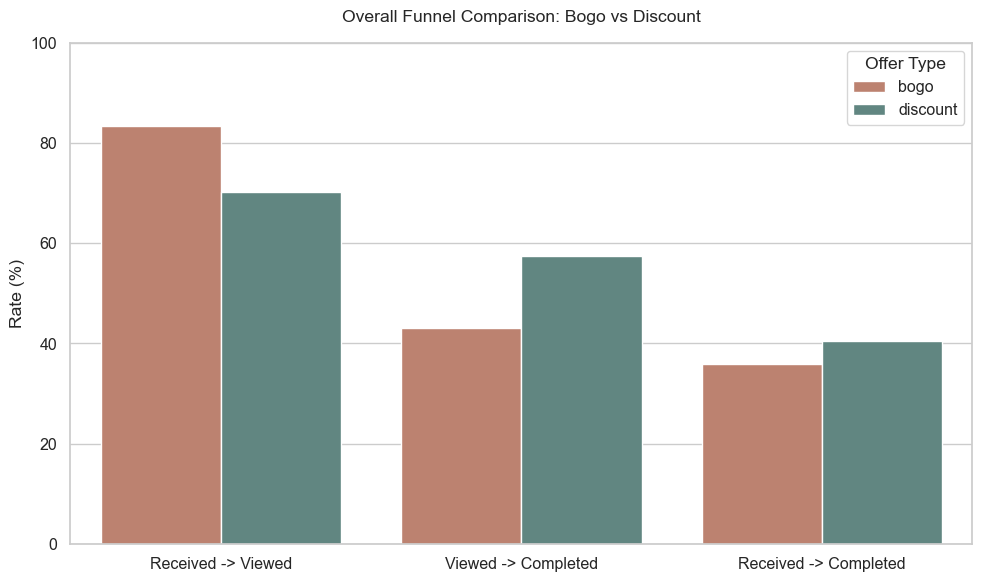

In [14]:
# 1) 공통 스타일 + 전체 퍼널 비교

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", font_scale=1.05)

# 한글 폰트가 깨지면 아래를 상황에 맞게 조정
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 6)

funnel_summary = seg_df.groupby('offer_type').agg(
    total_offers=('person', 'count'),
    viewed=('viewed_flag', 'sum'),
    completed=('completed_after_view_flag', 'sum')
).reset_index()

funnel_summary['view_rate(%)'] = (funnel_summary['viewed'] / funnel_summary['total_offers'] * 100).round(1)
funnel_summary['completion_rate(%)'] = (funnel_summary['completed'] / funnel_summary['viewed'] * 100).round(1)
funnel_summary['received_to_complete_rate(%)'] = (funnel_summary['completed'] / funnel_summary['total_offers'] * 100).round(1)

funnel_long = funnel_summary.melt(
    id_vars='offer_type',
    value_vars=['view_rate(%)', 'completion_rate(%)', 'received_to_complete_rate(%)'],
    var_name='stage',
    value_name='rate'
)

stage_order = ['view_rate(%)', 'completion_rate(%)', 'received_to_complete_rate(%)']
stage_labels = {
    'view_rate(%)': 'Received -> Viewed',
    'completion_rate(%)': 'Viewed -> Completed',
    'received_to_complete_rate(%)': 'Received -> Completed'
}

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=funnel_long,
    x='stage',
    y='rate',
    hue='offer_type',
    order=stage_order,
    palette=['#C97B63', '#5B8C85']
)

ax.set_title('Overall Funnel Comparison: Bogo vs Discount', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Rate (%)')
ax.set_xticklabels([stage_labels[s] for s in stage_order])
ax.legend(title='Offer Type')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


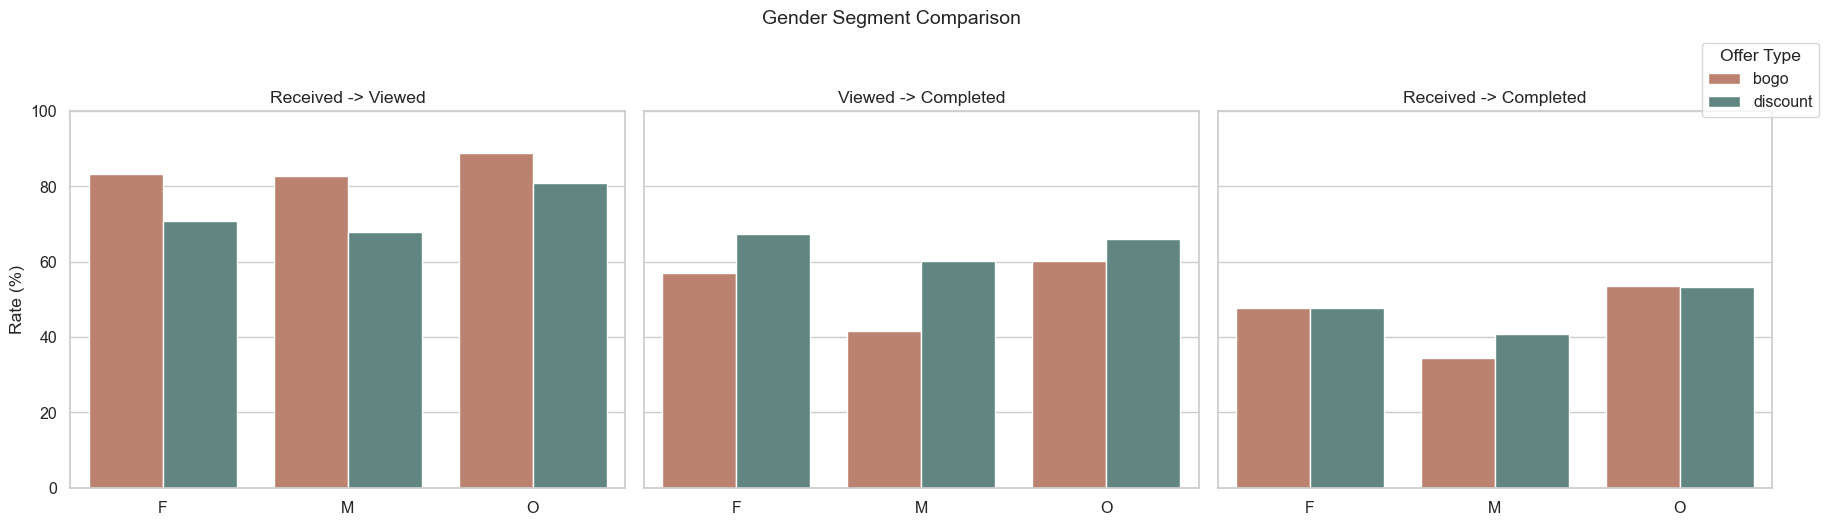

In [15]:
# 2) 성별 비교

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

metrics = ['view_rate(%)', 'completion_rate(%)', 'received_to_complete_rate(%)']
titles = ['Received -> Viewed', 'Viewed -> Completed', 'Received -> Completed']
palette = ['#C97B63', '#5B8C85']

for ax, metric, title in zip(axes, metrics, titles):
    sns.barplot(
        data=offer_type_gender,
        x='gender',
        y=metric,
        hue='offer_type',
        palette=palette,
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('Rate (%)' if ax == axes[0] else '')
    ax.set_ylim(0, 100)
    ax.legend_.remove()

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, title='Offer Type', loc='upper right', bbox_to_anchor=(1.02, 1))
fig.suptitle('Gender Segment Comparison', y=1.05, fontsize=14)
plt.tight_layout()
plt.show()


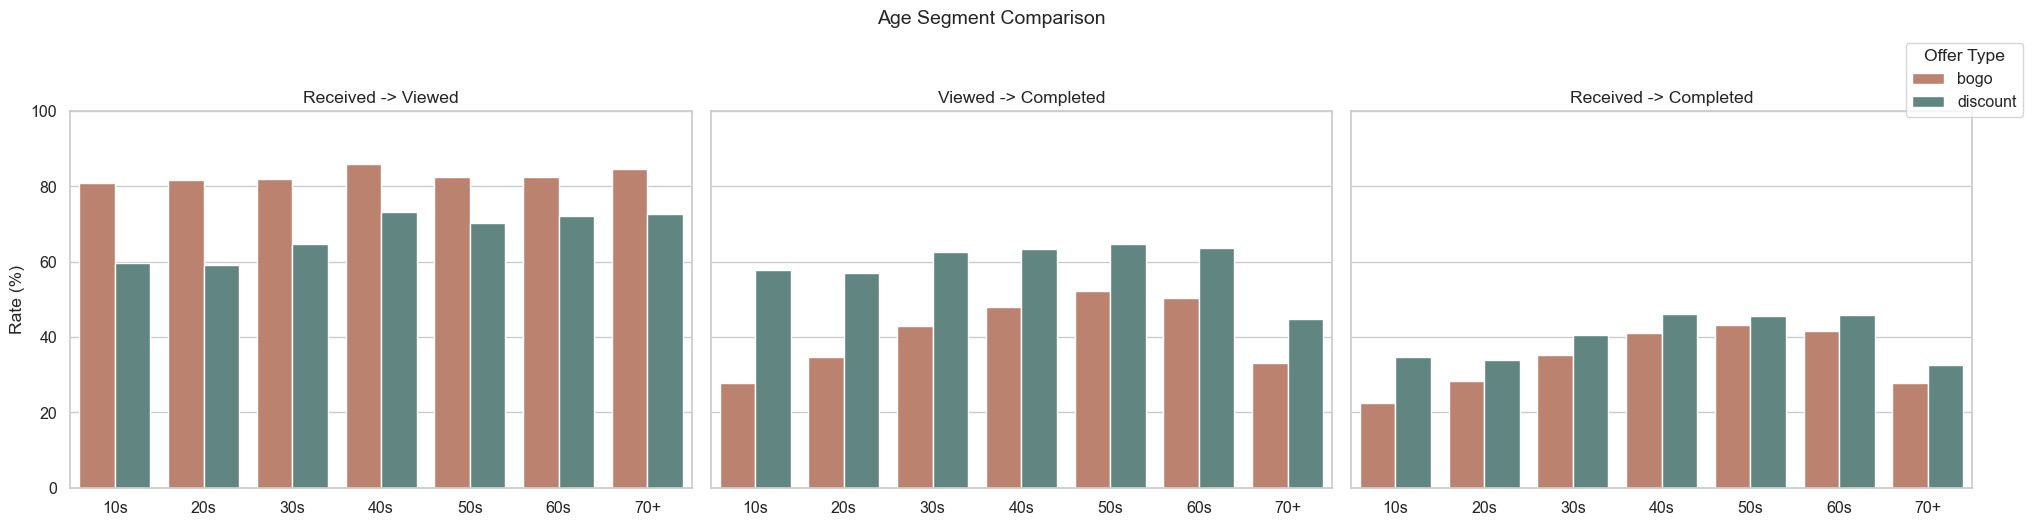

In [16]:
# 3) 연령대 비교

fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

metrics = ['view_rate(%)', 'completion_rate(%)', 'received_to_complete_rate(%)']
titles = ['Received -> Viewed', 'Viewed -> Completed', 'Received -> Completed']
palette = ['#C97B63', '#5B8C85']

for ax, metric, title in zip(axes, metrics, titles):
    sns.barplot(
        data=offer_type_age,
        x='age_group',
        y=metric,
        hue='offer_type',
        palette=palette,
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('Rate (%)' if ax == axes[0] else '')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=0)
    ax.legend_.remove()

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, title='Offer Type', loc='upper right', bbox_to_anchor=(1.02, 1))
fig.suptitle('Age Segment Comparison', y=1.05, fontsize=14)
plt.tight_layout()
plt.show()


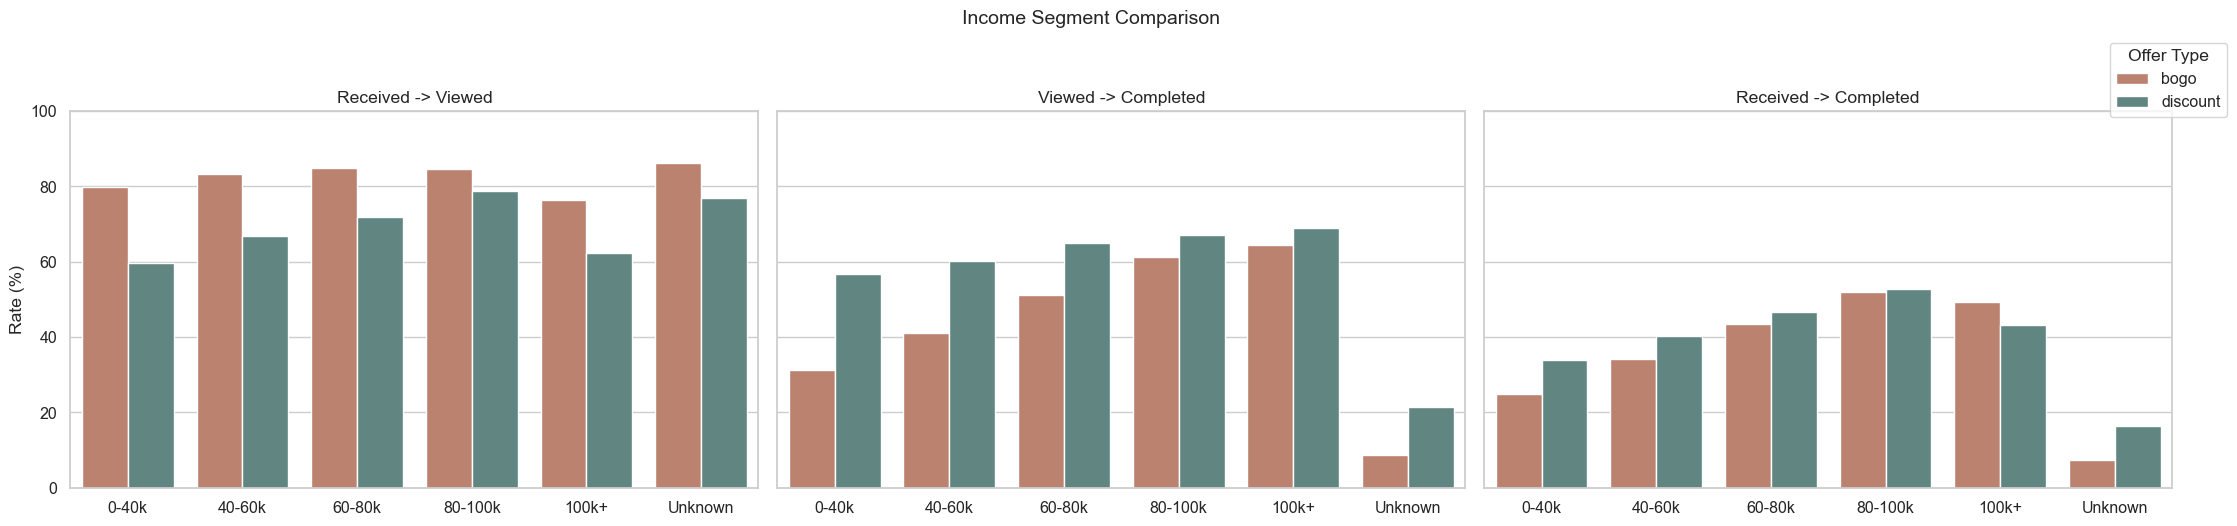

In [17]:
# 4) 소득대 비교

income_order = ['0-40k', '40-60k', '60-80k', '80-100k', '100k+', 'Unknown']

offer_type_income_plot = offer_type_income.copy()
offer_type_income_plot['income_group'] = pd.Categorical(
    offer_type_income_plot['income_group'],
    categories=income_order,
    ordered=True
)
offer_type_income_plot = offer_type_income_plot.sort_values('income_group')

fig, axes = plt.subplots(1, 3, figsize=(22, 5), sharey=True)

metrics = ['view_rate(%)', 'completion_rate(%)', 'received_to_complete_rate(%)']
titles = ['Received -> Viewed', 'Viewed -> Completed', 'Received -> Completed']
palette = ['#C97B63', '#5B8C85']

for ax, metric, title in zip(axes, metrics, titles):
    sns.barplot(
        data=offer_type_income_plot,
        x='income_group',
        y=metric,
        hue='offer_type',
        palette=palette,
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('Rate (%)' if ax == axes[0] else '')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=0)
    ax.legend_.remove()

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, title='Offer Type', loc='upper right', bbox_to_anchor=(1.02, 1))
fig.suptitle('Income Segment Comparison', y=1.05, fontsize=14)
plt.tight_layout()
plt.show()


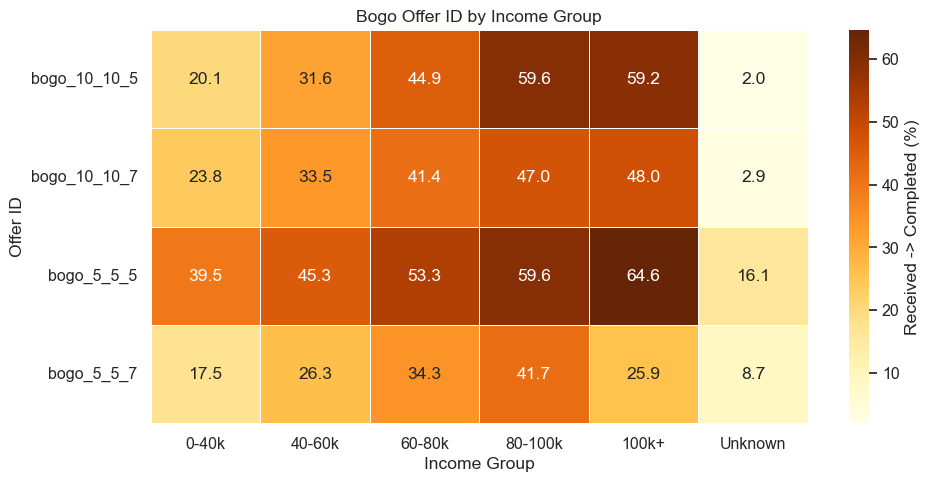

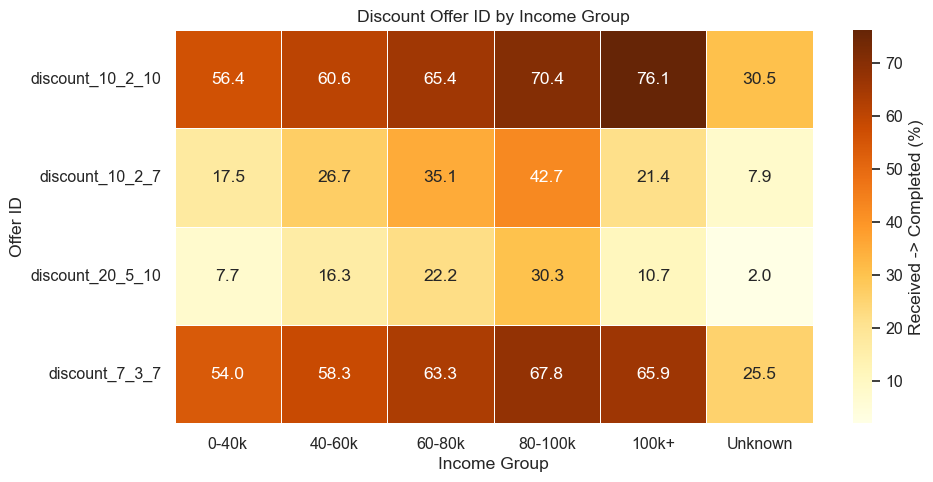

In [18]:
# 5) offer_id 보조 시각화: 히트맵

# offer_id_income에는 offer_id, income_group, received_to_complete_rate(%)가 있어야 함
heatmap_df = offer_id_income.copy()

income_order = ['0-40k', '40-60k', '60-80k', '80-100k', '100k+', 'Unknown']
heatmap_df['income_group'] = pd.Categorical(
    heatmap_df['income_group'],
    categories=income_order,
    ordered=True
)

for offer_type in heatmap_df['offer_id'].str.split('_').str[0].unique():
    temp = heatmap_df[heatmap_df['offer_id'].str.startswith(offer_type)].copy()
    pivot = temp.pivot(index='offer_id', columns='income_group', values='received_to_complete_rate(%)')
    pivot = pivot[income_order]

    plt.figure(figsize=(10, 5))
    sns.heatmap(
        pivot,
        annot=True,
        fmt='.1f',
        cmap='YlOrBr',
        linewidths=0.5,
        cbar_kws={'label': 'Received -> Completed (%)'}
    )
    plt.title(f'{offer_type.capitalize()} Offer ID by Income Group')
    plt.xlabel('Income Group')
    plt.ylabel('Offer ID')
    plt.tight_layout()
    plt.show()
